In [ ]:
from openpyxl import load_workbook
from openpyxl.cell.cell import Cell
from typing import Dict, Any, List, Optional
from openpyxl.utils.cell import coordinate_from_string, column_index_from_string, get_column_letter
import re
import pandas as pd
from docx.oxml.shared import qn

from docx import Document
from docx.shared import Cm, Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.style import WD_STYLE_TYPE
from datetime import datetime

pd.set_option('display.min_rows', 22)
pd.set_option('display.max_columns', None)

In [3]:
force_file_path = "force_file5.xlsx"
plan_file_path = "plan_file.xlsx"

In [4]:
def build_protocol_df(protocol_numbers, pct_static_values, matrix):
    if not matrix:
        return pd.DataFrame(columns=['row_idx', 'protocol_number', 'pct_static', 'v1', 'v2', 'v3'])

    n_rows = len(matrix)
    n_cols = len(matrix[0])
    n_blocks_in_matrix = n_cols // 3
    n_blocks = min(len(protocol_numbers), len(pct_static_values), n_blocks_in_matrix)

    records = []
    for b in range(n_blocks):
        p = protocol_numbers[b]
        pct = pct_static_values[b]
        c0, c1, c2 = b*3, b*3+1, b*3+2

        for r in range(n_rows):
            v1, v2, v3 = matrix[r][c0], matrix[r][c1], matrix[r][c2]
            # можно добавить фильтр пустых строк, если нужно:
            # if all(x in (None, '') for x in (v1, v2, v3)): continue
            records.append({
                'row_idx': r + 6,           # реальный номер строки Excel (если стартовали с 6)
                'protocol_number': p,
                'pct_static': pct,
                'v': v1,
                'p': v2,
                'f': v3,
            })

    return pd.DataFrame(records)

In [5]:
def read_step_blocks(ws, start_col_letter='F', start_row=6, block_width=3, gap=1):
    start_col = column_index_from_string(start_col_letter)
    step = block_width + gap

    # Список всех потенциальных колонок (F,G,H, J,K,L, N,O,P, ...)
    col_indices = []
    c = start_col
    while c <= ws.max_column:
        for i in range(block_width):
            if c + i <= ws.max_column:
                col_indices.append(c + i)
        c += step
    if not col_indices:
        return []

    min_c, max_c = col_indices[0], col_indices[-1]
    offset = min_c  # для индексации в кортеже iter_rows

    data = []
    last_nonempty_row = -1
    rightmost_used_idx = -1  # индекс в col_indices (самый правый реально использованный столбец)

    # Один проход по строкам, без Cell-объектов
    for r, row_vals in enumerate(ws.iter_rows(min_row=start_row, max_row=ws.max_row,
                                              min_col=min_c, max_col=max_c,
                                              values_only=True), start=start_row):
        # извлекаем только нужные колонки из окна [min_c..max_c]
        picked = [row_vals[c - offset] for c in col_indices]
        # проверяем непустоту и самый правый реально используемый столбец
        any_nonempty = False
        for j, v in enumerate(picked):
            if v not in (None, ''):
                any_nonempty = True
                if j > rightmost_used_idx:
                    rightmost_used_idx = j
        data.append(picked)
        if any_nonempty:
            last_nonempty_row = r

    # Обрезаем пустой «хвост» по строкам и по столбцам (справа)
    if last_nonempty_row == -1 or rightmost_used_idx == -1:
        return []

    rows_to = last_nonempty_row - start_row + 1
    cols_to = rightmost_used_idx + 1
    data = [row[:cols_to] for row in data[:rows_to]]
    return data  # матрица: строки x столбцы (F,G,H, J,K,L, ... до реально заполненных)

In [6]:
def values_by_step(ws, start_addr='G2', step_cols=4, stop_when_empty=True, max_col=None):
    col_letter, row = coordinate_from_string(start_addr)
    col = column_index_from_string(col_letter)

    # если не задали верхнюю границу — идём до первой пустой
    vals = []
    while True:
        addr = f"{get_column_letter(col)}{row}"
        v = ws[addr].value
        if stop_when_empty and (v is None or v == ""):
            break
        vals.append(v)
        col += step_cols
        if max_col and col > max_col:
            break
    return vals

def clean_protocol_number(raw: str) -> str:
    # Удаляем лидирующее "№" и лишние пробелы
    raw = raw.strip()
    raw = re.sub(r"^[№#\s]*", '', raw, flags=re.IGNORECASE)
    return raw.strip()

def extract_percent_from_text(text: str) -> Optional[float]:
    # Ожидается вид "Pст (1%)" — извлекаем число в скобках
    # Поддержка вариантов с запятой: 1,5%
    m = re.search(r"\(([-+]?\d+(?:[\.,]\d+)?)%\)", text)
    if not m:
        # fallback: искать первое число, затем знак %
        m = re.search(r"([-+]?\d+(?:[\.,]\d+)?)\s*%", text)
    if not m:
        return None
    try:
        return float(m.group(1).replace(',', '.'))
    except ValueError:
        return None

In [7]:
wb = load_workbook(filename=force_file_path, data_only=True, read_only=True)

force_protocol_dfs = pd.DataFrame()
sheets_data: List[Dict[str, Any]] = []
for ws in wb.worksheets:
    # Общие значения для листа
    energy_j = ws['C5'].value  # Энергия удара, Дж
    velocity_ms = ws['D5'].value  # Скорость удара, м/с
    force_n = ws['E5'].value  # Сила удара (P), Н

    # получение номеров протоколов
    protocol_numbers = values_by_step(ws, 'G2', step_cols=4, stop_when_empty=True)
    protocol_numbers = [clean_protocol_number(str(n)) for n in protocol_numbers]
    
    # получение процентов статического поджатия
    pct_static_values = values_by_step(ws, 'G4', step_cols=4, stop_when_empty=True)
    pct_static_values = [extract_percent_from_text(str(v)) for v in pct_static_values]

    # получение данных для каждого протокола
    matrix = read_step_blocks(ws, start_col_letter='F', start_row=6, block_width=3, gap=1)

    force_protocol_df = build_protocol_df(protocol_numbers, pct_static_values, matrix)
    force_protocol_df.drop(columns=['row_idx'], inplace=True)

    force_protocol_df['energy_j'] = energy_j
    force_protocol_df['velocity_ms'] = velocity_ms
    force_protocol_df['force_n'] = force_n

    force_protocol_dfs = pd.concat([force_protocol_dfs, force_protocol_df], ignore_index=True)

force_protocol_dfs

,protocol_number,pct_static,v,p,f,energy_j,velocity_ms,force_n
0,133,1.0,0.000000e+00,0.0,0.000367,25,3.0,108826
1,133,1.0,5.712865e-07,0.0,0.000380,25,3.0,108826
2,133,1.0,1.142573e-06,0.0,0.000391,25,3.0,108826
3,133,1.0,1.999502e-06,0.0,0.000401,25,3.0,108826
4,133,1.0,2.570788e-06,0.0,0.000408,25,3.0,108826
5,133,1.0,3.427716e-06,0.0,0.000413,25,3.0,108826
6,133,1.0,3.999002e-06,0.0,0.000415,25,3.0,108826
7,133,1.0,4.855930e-06,0.0,0.000414,25,3.0,108826
8,133,1.0,5.427217e-06,0.0,0.000408,25,3.0,108826
9,133,1.0,6.284145e-06,0.0,0.000398,25,3.0,108826


In [8]:
wb = load_workbook(filename=plan_file_path, data_only=True, read_only=True)
ws = wb.active

def parse_pct(text):
    if text is None:
        return None
    m = re.search(r'\(([\d.,]+)\s*%?\)', str(text))
    return float(m.group(1).replace(',', '.')) if m else None

# Диапазоны
data_start_row = 8
header_start_row = 7
step = 3

data_min_c = column_index_from_string('C')
data_max_c = column_index_from_string('V')

prot_min_c = column_index_from_string('N')
prot_max_c = column_index_from_string('X')

# Заголовки данных (только C:V)
header_row_for_data = 5
data_headers = [ws.cell(row=5, column=c).value or get_column_letter(c)
                for c in range(column_index_from_string('C'), column_index_from_string('M') + 1)]

# Pст проценты из N5:X5
pstat_labels_row = 5
pstat_labels = next(ws.iter_rows(min_row=pstat_labels_row, max_row=pstat_labels_row,
                                 min_col=prot_min_c, max_col=prot_max_c, values_only=True))
pstat_pct_by_col = {prot_min_c + i: parse_pct(v) for i, v in enumerate(pstat_labels)}

records = []
r_data, r_head = data_start_row, header_start_row

while r_data <= ws.max_row:
    prot_row = next(ws.iter_rows(min_row=r_head, max_row=r_head,
                                 min_col=prot_min_c, max_col=prot_max_c,
                                 values_only=True))
    data_row = next(ws.iter_rows(min_row=r_data, max_row=r_data,
                                 min_col=data_min_c, max_col=data_max_c,
                                 values_only=True))
    # значения p_static_value из той же строки r_data по колонкам N:X
    pstatic_values_row = next(ws.iter_rows(min_row=r_data, max_row=r_data,
                                           min_col=prot_min_c, max_col=prot_max_c,
                                           values_only=True))

    if all(p in (None, '') for p in prot_row) and all(v in (None, '') for v in data_row):
        break
    if all(v in (None, '') for v in data_row):
        break

    for i, p in enumerate(prot_row):
        if p in (None, ''):
            continue
        col_idx = prot_min_c + i
        rec = {
            'excel_row': r_data,
            'protocol_number': p,
            'p_static': pstat_pct_by_col.get(col_idx),
            'p_static_value': pstatic_values_row[i],  # только в этот столбец, без добавления N:X в df
        }
        # добавляем только C:V
        rec.update({col: val for col, val in zip(data_headers, data_row)})
        records.append(rec)

    r_data += step
    r_head += step

plan_protocol_df = pd.DataFrame(records)
needed = ['excel_row', 'protocol_number', 'p_static', 'p_static_value'] + data_headers
plan_protocol_df = plan_protocol_df.loc[:, [c for c in needed if c in plan_protocol_df.columns]]
plan_protocol_df.drop(columns=['excel_row'], inplace=True)
plan_protocol_df['protocol_number'] = plan_protocol_df['protocol_number'].astype(str).map(clean_protocol_number)
plan_protocol_df

,protocol_number,p_static,p_static_value,L1/L2,L1 (м),d1 (м),m1 (кг),L2 (м),d2 (м),Т (с),"А, (Дж)","V, (м/с)","С1,2 (кг/с)","Р, (Н)"
0,1,1.0,2439.865368,1,0.16,0.048,1.13,0.16,0.048,0.000062,25,6.651901,73358.4384,243986.536797
1,2,5.0,12199.326840,1,0.16,0.048,1.13,0.16,0.048,0.000062,25,6.651901,73358.4384,243986.536797
2,3,8.0,19518.922944,1,0.16,0.048,1.13,0.16,0.048,0.000062,25,6.651901,73358.4384,243986.536797
3,4,10.0,24398.653680,1,0.16,0.048,1.13,0.16,0.048,0.000062,25,6.651901,73358.4384,243986.536797
4,5,12.0,29278.384416,1,0.16,0.048,1.13,0.16,0.048,0.000062,25,6.651901,73358.4384,243986.536797
5,6,25.0,60996.634199,1,0.16,0.048,1.13,0.16,0.048,0.000062,25,6.651901,73358.4384,243986.536797
6,7,50.0,121993.268398,1,0.16,0.048,1.13,0.16,0.048,0.000062,25,6.651901,73358.4384,243986.536797
7,8,75.0,182989.902598,1,0.16,0.048,1.13,0.16,0.048,0.000062,25,6.651901,73358.4384,243986.536797
8,9,100.0,243986.536797,1,0.16,0.048,1.13,0.16,0.048,0.000062,25,6.651901,73358.4384,243986.536797
9,10,150.0,365979.805195,1,0.16,0.048,1.13,0.16,0.048,0.000062,25,6.651901,73358.4384,243986.536797


In [13]:
df = force_protocol_dfs[force_protocol_dfs['protocol_number'] == "198"]

C:\Users\Eugene\AppData\Local\Temp\ipykernel_15788\2166471467.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['f'] = df['f'].clip(lower=0)
C:\Users\Eugene\AppData\Local\Temp\ipykernel_15788\2166471467.py:91: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  S = np.trapz(y[i0:i1+1], x[i0:i1+1])


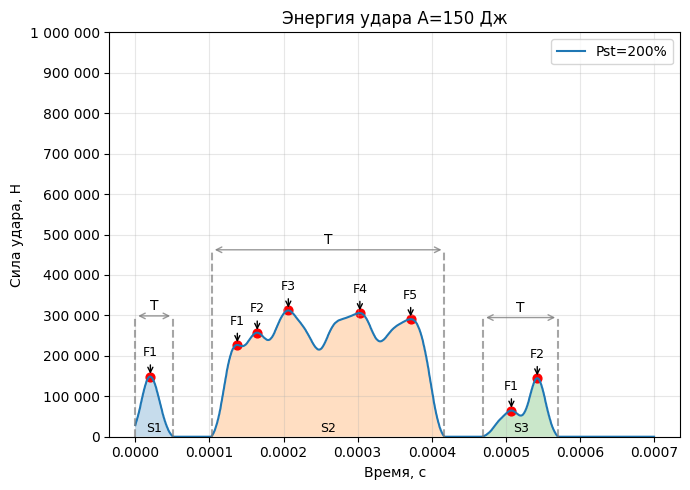

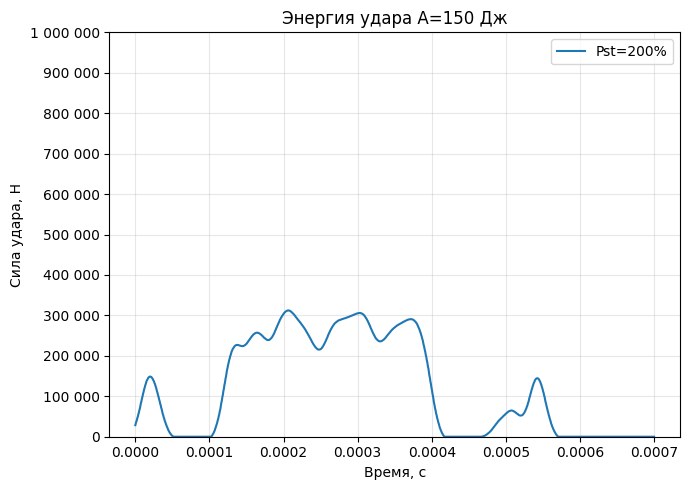

,pulse_id,extremum_id,extremum_type,v,f,duration_v,area,v_start,v_end
0,1,1,max,0.000020,148716.82270,0.000051,4.186331,0.000000,0.000051
1,2,1,max,0.000138,227007.70120,0.000314,74.013044,0.000103,0.000417
2,2,2,max,0.000164,257246.92110,0.000314,74.013044,0.000103,0.000417
3,2,3,max,0.000206,312253.02640,0.000314,74.013044,0.000103,0.000417
4,2,4,max,0.000303,305920.38480,0.000314,74.013044,0.000103,0.000417
5,2,5,max,0.000372,290727.62470,0.000314,74.013044,0.000103,0.000417
6,3,1,max,0.000507,64772.44443,0.000101,6.092157,0.000469,0.000570
7,3,2,max,0.000542,144701.29100,0.000101,6.092157,0.000469,0.000570


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import pandas as pd

p_static = int(df['pct_static'].mean())
energy_j = int(df['energy_j'].mean())

df['f'] = df['f'].clip(lower=0)

# исходные данные
d = df[['v', 'f']].dropna().sort_values('v')
x = d['v'].to_numpy()
y = d['f'].to_numpy()

# пики
try:
    from scipy.signal import find_peaks
    peaks, _   = find_peaks(y,  prominence=1e-6)
    troughs, _ = find_peaks(-y, prominence=1e-6)
except ImportError:
    dy = np.gradient(y, x)
    s = np.sign(dy)
    peaks   = np.where((s[:-1] > 0) & (s[1:] < 0))[0] + 1
    troughs = np.where((s[:-1] < 0) & (s[1:] > 0))[0] + 1

# фильтрация экстремумов
MIN_F = 1_000
peaks   = peaks[y[peaks]   >= MIN_F]
troughs = troughs[y[troughs] >= MIN_F]
peaks   = peaks[y[peaks]   >= 0]
troughs = troughs[y[troughs] >= 0]

# ==== 1) параметры выделения импульсов ====
ON_THR  = 1_000
OFF_THR = 1_000

above_on  = y >= ON_THR
above_off = y >= OFF_THR

starts = np.where((~above_on[:-1])  & (above_on[1:]))[0]  + 1
stops  = np.where((above_off[:-1]) & (~above_off[1:]))[0] + 1

# если график сразу начинается выше порога — первая область
if above_on[0]:
    starts = np.r_[0, starts]

# починка непарных случаев
if len(stops) and len(starts):
    if stops[0] < starts[0]:
        stops = stops[1:]
    if len(starts) > len(stops):
        stops = np.r_[stops, len(y)-1]
elif len(starts) and not len(stops):
    stops = np.array([len(y)-1])
elif len(stops) and not len(starts):
    starts = np.array([0])

pulse_windows = [(s, e) for s, e in zip(starts, stops) if e - s > 2]

# ==== 2) график ====
plt.figure(figsize=(7,5))
plt.plot(x, y, linewidth=1.5, label=f'Pst={p_static}%')

# ==== 3) выделение импульсов + верхняя стрелка "T" ====
areas = []
pulse_data = []
max_h_used = 0.0  # чтобы потом адекватно задать ylim

for k, (i0, i1) in enumerate(pulse_windows, 1):
    # заливка области
    plt.fill_between(x[i0:i1+1], 0, y[i0:i1+1], alpha=0.25)

    # «штыри»
    h = y[i0:i1+1].max() + 150_000
    max_h_used = max(max_h_used, h)
    plt.vlines(x[i0], 0, h, colors='gray', linestyles='--', alpha=0.7)
    plt.vlines(x[i1], 0, h, colors='gray', linestyles='--', alpha=0.7)

    # верхняя двусторонняя стрелка (коннектор) и подпись T
    xm = (x[i0] + x[i1]) / 2
    plt.annotate(
        '', xy=(x[i1], h), xytext=(x[i0], h),
        arrowprops=dict(arrowstyle='<->', lw=1, color='gray', alpha=0.8)
    )
    # небольшой вертикальный отступ над стрелкой
    t_offset = 0.02 * max(y.max(), 1.0)
    plt.text(xm, h + t_offset, 'T', ha='center', va='bottom', fontsize=10)

    # площадь и длительность
    S = np.trapz(y[i0:i1+1], x[i0:i1+1])
    duration_v = x[i1] - x[i0]
    v_start, v_end = float(x[i0]), float(x[i1])

    # максимумы внутри области — и на график, и в df
    in_pulse_max = peaks[(peaks >= i0) & (peaks <= i1)]
    for j, p in enumerate(in_pulse_max, 1):
        plt.scatter(x[p], y[p], c='r', s=40)
        plt.annotate(
            f'F{j}', xy=(x[p], y[p]),
            xytext=(x[p], y[p] + 50_000),
            arrowprops=dict(arrowstyle='->', lw=1),
            ha='center', fontsize=9
        )

    areas.append((k, S, xm))

    if len(in_pulse_max) == 0:
        pulse_data.append({
            "pulse_id": k, "extremum_id": None, "extremum_type": None,
            "v": None, "f": None,
            "duration_v": float(duration_v), "area": float(S),
            "v_start": v_start, "v_end": v_end
        })
    else:
        for j, p in enumerate(in_pulse_max, 1):
            pulse_data.append({
                "pulse_id": k, "extremum_id": j, "extremum_type": "max",
                "v": float(x[p]), "f": float(y[p]),
                "duration_v": float(duration_v), "area": float(S),
                "v_start": v_start, "v_end": v_end
            })

# подписи площадей S1, S2...
for k, S, xm in areas:
    plt.text(xm, max(ON_THR*1.1, y.max() * 0.01), f'S{k}',
             ha='center', va='bottom', fontsize=9)

# оформление
fmt_int = FuncFormatter(lambda val, pos: f'{int(val):,}'.replace(',', ' '))
plt.xlabel('Время, с')
plt.ylabel('Сила удара, Н')
plt.title(f'Энергия удара A={energy_j} Дж')

# ось Y — так, чтобы влезали верхние стрелки
upper = max(1_000_000, max_h_used * 0.05, y.max() * 1.05)
plt.ylim(0, upper)

plt.yticks(np.arange(0, 1_000_001, 100_000))
plt.gca().yaxis.set_major_formatter(fmt_int)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
plt.plot(x, y, linewidth=1.5, label=f'Pst={p_static}%')

plt.xlabel('Время, с')
plt.ylabel('Сила удара, Н')
plt.title(f'Энергия удара A={energy_j} Дж')

# тот же формат оси Y (можно оставить авто, если хочешь)
plt.ylim(0, 1_000_000)
plt.yticks(np.arange(0, 1_000_001, 100_000))
plt.gca().yaxis.set_major_formatter(fmt_int)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# таблица с максимумами
pulse_df = pd.DataFrame(pulse_data)
pulse_df

In [24]:
import os, sys
import django
PROJECTPATH = 'C:/projects/ergo_ms/api'
sys.path.insert(0, PROJECTPATH)
os.environ.setdefault("DJANGO_SETTINGS_MODULE", "src.config.patterns.development")
os.chdir(PROJECTPATH)
django.setup()

[INFO] config.database: Успешное тестовое подключение к базе данных 'default' (тип: django.db.backends.postgresql)


In [29]:
import pandas as pd
from src.core.utils.database.dbconfig import DBConfig
from src.core.utils.database.base import SqlAlchemyManager

def get_analysis_by_protocol_number(protocol_number: str) -> dict:
    """
    Получает всю информацию об анализе по номеру протокола
    
    Args:
        protocol_number (str): Номер протокола
        
    Returns:
        dict: Словарь с DataFrame'ами всех связанных данных
    """
    
    # Инициализация подключения к базе данных
    with DBConfig() as db_config:
        db_manager = SqlAlchemyManager(db_config)
        
        try:
            # 1. Основная информация об анализе
            analysis_query = """
                SELECT 
                    ia.id,
                    ia.title,
                    ia.description,
                    ia.analysis_type,
                    ia.status,
                    ia.created_at,
                    ia.updated_at,
                    ia.started_at,
                    ia.completed_at,
                    ia.protocol_number,
                    ia.p_static,
                    ia.energy_j,
                    ia.detailed_image,
                    ia.plain_image,
                    ia.error_message,
                    ia.task_id,
                    u.username as user_username,
                    u.email as user_email
                FROM impuls_analysis_impulsanalysis ia
                LEFT JOIN auth_user u ON ia.user_id = u.id
                WHERE ia.protocol_number = %(protocol_number)s
            """
            
            analysis_df = db_manager.fetchall(
                lambda: (analysis_query, {'protocol_number': protocol_number})
            )
            
            if analysis_df.empty:
                return {"error": f"Анализ с номером протокола '{protocol_number}' не найден"}
            
            analysis_id = analysis_df.iloc[0]['id']
            
            # 2. Файлы анализа
            files_query = """
                SELECT 
                    if.id,
                    if.file_type,
                    if.file,
                    if.original_filename,
                    if.file_size,
                    if.uploaded_at
                FROM impuls_analysis_impulsfile if
                WHERE if.analysis_id = %(analysis_id)s
            """
            
            files_df = db_manager.fetchall(
                lambda: (files_query, {'analysis_id': analysis_id})
            )
            
            # 3. Протоколы анализа
            protocols_query = """
                SELECT 
                    ip.id,
                    ip.protocol_file,
                    ip.generated_at,
                    ip.file_size
                FROM impuls_analysis_impulsprotocol ip
                WHERE ip.analysis_id = %(analysis_id)s
                ORDER BY ip.generated_at DESC
            """
            
            protocols_df = db_manager.fetchall(
                lambda: (protocols_query, {'analysis_id': analysis_id})
            )
            
            # 4. Записи расчета силы
            force_records_query = """
                SELECT 
                    ifr.id,
                    ifr.sheet_title,
                    ifr.protocol_number,
                    ifr.pct_static,
                    ifr.v,
                    ifr.p,
                    ifr.f,
                    ifr.energy_j,
                    ifr.velocity_ms,
                    ifr.force_n,
                    ifr.created_at
                FROM impuls_analysis_impulsforcerecord ifr
                WHERE ifr.protocol_number = %(protocol_number)s
                ORDER BY ifr.created_at DESC
            """
            
            force_records_df = db_manager.fetchall(
                lambda: (force_records_query, {'protocol_number': protocol_number})
            )
            
            # 5. Записи плана эксперимента
            plan_records_query = """
                SELECT 
                    ipr.id,
                    ipr.protocol_number,
                    ipr.p_static,
                    ipr.p_static_value,
                    ipr.l1_l2_ratio,
                    ipr.l1_m,
                    ipr.d1_m,
                    ipr.m1_kg,
                    ipr.l2_m,
                    ipr.d2_m,
                    ipr.t_s,
                    ipr.a_j,
                    ipr.v_ms,
                    ipr.c12_kg_s,
                    ipr.p_n,
                    ipr.created_at
                FROM impuls_analysis_impulsplanrecord ipr
                WHERE ipr.protocol_number = %(protocol_number)s
                ORDER BY ipr.created_at DESC
            """
            
            plan_records_df = db_manager.fetchall(
                lambda: (plan_records_query, {'protocol_number': protocol_number})
            )
            
            # 6. Экстремумы импульсов
            extrema_query = """
                SELECT 
                    ie.id,
                    ie.pulse_id,
                    ie.extremum_id,
                    ie.extremum_type,
                    ie.v,
                    ie.f,
                    ie.duration_v,
                    ie.area,
                    ie.v_start,
                    ie.v_end,
                    ie.created_at
                FROM impuls_analysis_impulsextremum ie
                WHERE ie.analysis_id = %(analysis_id)s
                ORDER BY ie.pulse_id, ie.extremum_id
            """
            
            extrema_df = db_manager.fetchall(
                lambda: (extrema_query, {'analysis_id': analysis_id})
            )
            
            # Формируем результат
            result = {
                "analysis": analysis_df,
                "files": files_df,
                "protocols": protocols_df,
                "force_records": force_records_df,
                "plan_records": plan_records_df,
                "extrema": extrema_df,
                "summary": {
                    "protocol_number": protocol_number,
                    "analysis_id": analysis_id,
                    "total_files": len(files_df),
                    "total_protocols": len(protocols_df),
                    "total_force_records": len(force_records_df),
                    "total_plan_records": len(plan_records_df),
                    "total_extrema": len(extrema_df)
                }
            }
            
            return result
            
        except Exception as e:
            return {"error": f"Ошибка при получении данных: {str(e)}"}
        
        finally:
            db_manager.close()

def get_analysis_summary_by_protocol(protocol_number: str) -> pd.DataFrame:
    """
    Получает краткую сводку по анализу в виде одного DataFrame
    
    Args:
        protocol_number (str): Номер протокола
        
    Returns:
        pd.DataFrame: DataFrame с основной информацией об анализе
    """
    
    with DBConfig() as db_config:
        db_manager = SqlAlchemyManager(db_config)
        
        try:
            summary_query = """
                SELECT 
                    ia.id as analysis_id,
                    ia.title,
                    ia.status,
                    ia.analysis_type,
                    ia.protocol_number,
                    ia.p_static,
                    ia.energy_j,
                    ia.created_at,
                    ia.completed_at,
                    u.username as user_username,
                    COUNT(DISTINCT if.id) as files_count,
                    COUNT(DISTINCT ip.id) as protocols_count,
                    COUNT(DISTINCT ifr.id) as force_records_count,
                    COUNT(DISTINCT ipr.id) as plan_records_count,
                    COUNT(DISTINCT ie.id) as extrema_count
                FROM impuls_analysis_impulsanalysis ia
                LEFT JOIN auth_user u ON ia.user_id = u.id
                LEFT JOIN impuls_analysis_impulsfile if ON ia.id = if.analysis_id
                LEFT JOIN impuls_analysis_impulsprotocol ip ON ia.id = ip.analysis_id
                LEFT JOIN impuls_analysis_impulsforcerecord ifr ON ia.protocol_number = ifr.protocol_number
                LEFT JOIN impuls_analysis_impulsplanrecord ipr ON ia.protocol_number = ipr.protocol_number
                LEFT JOIN impuls_analysis_impulsextremum ie ON ia.id = ie.analysis_id
                WHERE ia.protocol_number = %(protocol_number)s
                GROUP BY ia.id, ia.title, ia.status, ia.analysis_type, 
                         ia.protocol_number, ia.p_static, ia.energy_j, 
                         ia.created_at, ia.completed_at, u.username
            """
            
            return db_manager.fetchall(
                lambda: (summary_query, {'protocol_number': protocol_number})
            )
            
        except Exception as e:
            print(f"Ошибка при получении сводки: {str(e)}")
            return pd.DataFrame()
        
        finally:
            db_manager.close()

In [ ]:
# Получение полной информации об анализе
protocol_number = "198"  # Замените на нужный номер протокола

analysis_data = get_analysis_by_protocol_number(protocol_number)

if "error" in analysis_data:
    print(f"Ошибка: {analysis_data['error']}")
else:
    print("\n=== ОСНОВНАЯ ИНФОРМАЦИЯ ===")
    display(analysis_data['analysis'])
    
    if not analysis_data['force_records'].empty:
        print("\n=== ЗАПИСИ РАСЧЕТА СИЛЫ ===")
        display(analysis_data['force_records'])
    
    if not analysis_data['plan_records'].empty:
        print("\n=== ЗАПИСИ ПЛАНА ЭКСПЕРИМЕНТА ===")
        display(analysis_data['plan_records'])
    
    if not analysis_data['extrema'].empty:
        print("\n=== ЭКСТРЕМУМЫ ИМПУЛЬСОВ ===")
        display(analysis_data['extrema'])

# Получение краткой сводки
print("\n=== КРАТКАЯ СВОДКА ===")
summary_df = get_analysis_summary_by_protocol(protocol_number)
display(summary_df)


=== ОСНОВНАЯ ИНФОРМАЦИЯ ===


,id,title,description,analysis_type,status,created_at,updated_at,started_at,completed_at,protocol_number,p_static,energy_j,detailed_image,plain_image,error_message,task_id,user_username,user_email
0,2ba914d7-c75c-4a80-9098-ac5e9372d9e0,Протокол 198,Анализ по протоколу 198,standard,completed,2025-09-04 19:39:27.320492+00:00,2025-09-04 19:39:28.537995+00:00,None,2025-09-04 19:39:28.537995+00:00,198,200.0,150.0,impuls_analysis/analyses/2ba914d7-c75c-4a80-90...,impuls_analysis/analyses/2ba914d7-c75c-4a80-90...,,None,Dohao,muzalevskij00@mail.ru



=== ЗАПИСИ РАСЧЕТА СИЛЫ ===


,id,sheet_title,protocol_number,pct_static,v,p,f,energy_j,velocity_ms,force_n,created_at
0,66033,150 Дж,198,200.0,6.767978e-04,0.0000,0.366443,150.0,7.3,266567.0,2025-09-04 17:48:39.659808+00:00
1,66066,150 Дж,198,200.0,6.999306e-04,0.0000,0.208780,150.0,7.3,266567.0,2025-09-04 17:48:39.659808+00:00
2,66065,150 Дж,198,200.0,6.990739e-04,0.0000,0.210995,150.0,7.3,266567.0,2025-09-04 17:48:39.659808+00:00
3,66064,150 Дж,198,200.0,6.985027e-04,0.0000,0.214113,150.0,7.3,266567.0,2025-09-04 17:48:39.659808+00:00
4,66063,150 Дж,198,200.0,6.976459e-04,0.0000,0.218199,150.0,7.3,266567.0,2025-09-04 17:48:39.659808+00:00
5,66062,150 Дж,198,200.0,6.970747e-04,0.0000,0.223305,150.0,7.3,266567.0,2025-09-04 17:48:39.659808+00:00
6,66061,150 Дж,198,200.0,6.962179e-04,0.0000,0.229465,150.0,7.3,266567.0,2025-09-04 17:48:39.659808+00:00
7,66060,150 Дж,198,200.0,6.956467e-04,0.0000,0.236701,150.0,7.3,266567.0,2025-09-04 17:48:39.659808+00:00
8,66059,150 Дж,198,200.0,6.950756e-04,0.0000,0.245016,150.0,7.3,266567.0,2025-09-04 17:48:39.659808+00:00
9,66058,150 Дж,198,200.0,6.942187e-04,0.0000,0.254397,150.0,7.3,266567.0,2025-09-04 17:48:39.659808+00:00



=== ЗАПИСИ ПЛАНА ЭКСПЕРИМЕНТА ===


,id,protocol_number,p_static,p_static_value,l1_l2_ratio,l1_m,d1_m,m1_kg,l2_m,d2_m,t_s,a_j,v_ms,c12_kg_s,p_n,created_at
0,198,198,200.0,533134.193091,5,0.8,0.048,5.68,0.16,0.048,0.000308,150.0,7.267524,73358.4384,266567.096545,2025-09-04 17:47:55.103809+00:00



=== ЭКСТРЕМУМЫ ИМПУЛЬСОВ ===


,id,pulse_id,extremum_id,extremum_type,v,f,duration_v,area,v_start,v_end,created_at
0,49,1,1,max,0.000020,148716.82270,0.000051,4.186331,0.000000,0.000051,2025-09-04 19:39:28.546994+00:00
1,50,2,1,max,0.000138,227007.70120,0.000314,74.012990,0.000103,0.000417,2025-09-04 19:39:28.546994+00:00
2,51,2,2,max,0.000164,257246.92110,0.000314,74.012990,0.000103,0.000417,2025-09-04 19:39:28.546994+00:00
3,52,2,3,max,0.000206,312253.02640,0.000314,74.012990,0.000103,0.000417,2025-09-04 19:39:28.546994+00:00
4,53,2,4,max,0.000303,305920.38480,0.000314,74.012990,0.000103,0.000417,2025-09-04 19:39:28.546994+00:00
5,54,2,5,max,0.000372,290727.62470,0.000314,74.012990,0.000103,0.000417,2025-09-04 19:39:28.546994+00:00
6,55,3,1,max,0.000507,64772.44443,0.000101,6.092157,0.000469,0.000570,2025-09-04 19:39:28.546994+00:00
7,56,3,2,max,0.000542,144701.29100,0.000101,6.092157,0.000469,0.000570,2025-09-04 19:39:28.546994+00:00



=== КРАТКАЯ СВОДКА ===


,analysis_id,title,status,analysis_type,protocol_number,p_static,energy_j,created_at,completed_at,user_username,files_count,protocols_count,force_records_count,plan_records_count,extrema_count
0,2ba914d7-c75c-4a80-9098-ac5e9372d9e0,Протокол 198,completed,standard,198,200.0,150.0,2025-09-04 19:39:27.320492+00:00,2025-09-04 19:39:28.537995+00:00,Dohao,0,0,1001,1,8


In [206]:
import math
def format_sig_plain(x: float, sig: int = 2, decimal_comma: bool = False) -> str:
    if x == 0 or not math.isfinite(x):
        s = "0" if x == 0 else str(x)
    else:
        exp = math.floor(math.log10(abs(x)))     # порядок
        scale = sig - 1 - exp                    # сколько знаков после точки нужно
        if scale >= 0:
            s = f"{x:.{scale}f}"                 # фикс. кол-во десятичных знаков
        else:
            s = f"{round(x, scale):.0f}"         # округление до десятков/сотен и т.п.
    return s.replace('.', ',') if decimal_comma else s

In [207]:
def create_impulse_tables(doc, extrema_df):
    grouped = extrema_df.groupby('pulse_id')

    for pulse_id, group in grouped:
        # Заголовок импульса
        impulse_header = doc.add_paragraph()
        impulse_header.alignment = WD_ALIGN_PARAGRAPH.CENTER
        impulse_header.paragraph_format.space_after = Pt(6)
        
        header_run = impulse_header.add_run(f"Импульс S{pulse_id}")
        header_run.font.name = 'Times New Roman'
        header_run.font.size = Pt(14)
        header_run.bold = True

        num_extrema = len(group)

        # Всего строк = 1 (заголовки) + num_extrema (макс. сила) + 2 (длительность, площадь)
        table_rows = 1 + num_extrema + 2
        table = doc.add_table(rows=table_rows, cols=3)
        table.style = 'Table Grid'
        table.alignment = WD_ALIGN_PARAGRAPH.CENTER

        # Заголовки
        header_cells = table.rows[0].cells
        header_cells[0].text = 'Параметр'
        header_cells[1].text = 'Мера измерения'
        header_cells[2].text = 'Значение'

        # Форматирование заголовков таблицы (жирный шрифт)
        for cell in header_cells:
            for paragraph in cell.paragraphs:
                for run in paragraph.runs:
                    run.font.name = 'Times New Roman'
                    run.font.size = Pt(14)
                    run.bold = True

        # --- Блок "Максимальное значение силы в точке" ---
        start_row = 1
        end_row = start_row + num_extrema - 1

        # Объединяем ячейки первой колонки
        a = table.cell(start_row, 0)
        b = table.cell(end_row, 0)
        a.merge(b)
        a.text = "Максимальное значение силы в точке"

        # Заполняем 2 и 3 колонки
        for i in range(num_extrema):
            row = table.rows[start_row + i]
            
            # Создаем текст с нижним индексом для F{i+1}
            cell_1 = row.cells[1]
            cell_1.text = ""  # Очищаем ячейку
            paragraph = cell_1.paragraphs[0]
            
            # Добавляем "F" обычным шрифтом
            run1 = paragraph.add_run("F")
            run1.font.name = 'Times New Roman'
            run1.font.size = Pt(14)
            
            # Добавляем число как нижний индекс
            run2 = paragraph.add_run(str(i+1))
            run2.font.name = 'Times New Roman'
            run2.font.size = Pt(14)
            run2.font.subscript = True
            
            # Добавляем ", H"
            run3 = paragraph.add_run(", H")
            run3.font.name = 'Times New Roman'
            run3.font.size = Pt(14)
            
            row.cells[2].text = f"{group['f'].iloc[i]:.2f}"  # сюда можно подставить значение силы

        # --- Длительность импульса ---
        duration_row = table.rows[end_row + 1]
        duration_row.cells[0].text = "Длительность импульса"
        duration_row.cells[1].text = "T, сек"
        duration = group['duration_v'].iloc[0]
        duration_row.cells[2].text = format_sig_plain(duration, 2, decimal_comma=True)

        # --- Площадь импульса ---
        area_row = table.rows[end_row + 2]
        area_row.cells[0].text = "Площадь импульса"
        area_row.cells[1].text = "S, усл.единиц²"
        area_row.cells[2].text = f"{group['area'].iloc[0]:.2f}"

        # Форматирование всех ячеек таблицы (Times New Roman 14)
        for row in table.rows:
            for cell in row.cells:
                for paragraph in cell.paragraphs:
                    for run in paragraph.runs:
                        run.font.name = 'Times New Roman'
                        run.font.size = Pt(14)

        # Добавляем отступ после таблицы
        doc.add_paragraph().paragraph_format.space_after = Pt(12)

In [216]:
def create_force_records_table(doc, force_records_df):
    """
    Создает таблицу с записями расчета силы
    
    Args:
        doc: Document объект
        force_records_df: DataFrame с данными force_records
    """
    if force_records_df.empty:
        return
    
    # Создаем таблицу
    num_rows = len(force_records_df) + 1  # +1 для заголовков
    table = doc.add_table(rows=num_rows, cols=4)
    table.style = 'Table Grid'
    table.alignment = WD_ALIGN_PARAGRAPH.CENTER
    
    # Заголовки таблицы
    header_cells = table.rows[0].cells
    header_cells[0].text = '№'
    header_cells[1].text = 'Время, с'
    header_cells[2].text = 'Сила удара, Н (Р)'
    
    # Создаем заголовок с нижним индексом для "F=10kHz"
    cell_3 = header_cells[3]
    cell_3.text = ""  # Очищаем ячейку
    paragraph = cell_3.paragraphs[0]
    paragraph.alignment = WD_ALIGN_PARAGRAPH.CENTER  # Выравнивание по центру
    
    # Добавляем "Сила удара, Н (фильтр Butterworth 10000Hz) (F="
    run1 = paragraph.add_run("Сила удара, Н (фильтр Butterworth 10000Hz) (F=")
    run1.font.name = 'Times New Roman'
    run1.font.size = Pt(14)
    run1.bold = True
    
    # Добавляем "kHz)"
    run3 = paragraph.add_run("10kHz)")
    run3.font.name = 'Times New Roman'
    run3.font.size = Pt(14)
    run3.bold = True
    
    # Форматирование заголовков таблицы (жирный шрифт и выравнивание по центру)
    for i, cell in enumerate(header_cells):
        if i != 3:  # 3-я ячейка уже отформатирована выше
            for paragraph in cell.paragraphs:
                paragraph.alignment = WD_ALIGN_PARAGRAPH.CENTER  # Выравнивание по центру
                for run in paragraph.runs:
                    run.font.name = 'Times New Roman'
                    run.font.size = Pt(14)
                    run.bold = True
    
    # Заполняем данные
    for idx, (_, row) in enumerate(force_records_df.iterrows(), 1):
        data_row = table.rows[idx]
        data_row.cells[0].text = str(idx)  # №
        data_row.cells[1].text = format_sig_plain(row['v'], 2, decimal_comma=True)  # Время, с
        data_row.cells[2].text = f"{row['p']:.2f}"  # Сила удара, Н (Р)
        data_row.cells[3].text = f"{row['f']:.2f}"  # Сила удара, Н (фильтр)
    
    # Форматирование всех ячеек таблицы (Times New Roman 14 и выравнивание по центру)
    for row in table.rows:
        for cell in row.cells:
            for paragraph in cell.paragraphs:
                paragraph.alignment = WD_ALIGN_PARAGRAPH.CENTER  # Выравнивание по центру
                for run in paragraph.runs:
                    run.font.name = 'Times New Roman'
                    run.font.size = Pt(14)

In [ ]:
def create_word_document(analysis_data):
    """
    Создает Word документ с более точным форматированием
    """
    
    doc = Document()
    
    # Настройка полей страницы
    sections = doc.sections
    for section in sections:
        section.top_margin = Cm(1.5)
        section.bottom_margin = Cm(2.0)
        section.left_margin = Cm(3.0)
        section.right_margin = Cm(1.5)
    
    # Добавляем заголовок с текущей датой
    current_date = datetime.now().strftime("%d.%m.%Y")
    
    # Первая строка - жирная
    title_paragraph = doc.add_paragraph()
    title_paragraph.alignment = WD_ALIGN_PARAGRAPH.CENTER
    title_paragraph.paragraph_format.line_spacing = 1.0
    title_paragraph.paragraph_format.space_after = Pt(0)
    
    protocol_number = analysis_data['analysis']['protocol_number'].iloc[0]

    title_run = title_paragraph.add_run(f"ПРОТОКОЛ № {protocol_number} от {current_date} г.")
    title_run.font.name = 'Times New Roman'
    title_run.font.size = Pt(14)
    title_run.bold = True
    
    # Вторая строка - обычная
    subtitle_paragraph = doc.add_paragraph()
    subtitle_paragraph.alignment = WD_ALIGN_PARAGRAPH.CENTER
    subtitle_paragraph.paragraph_format.line_spacing = 1.0
    subtitle_paragraph.paragraph_format.space_after = Pt(0)
    
    subtitle_run = subtitle_paragraph.add_run("Моделирование ударного импульса")
    subtitle_run.font.name = 'Times New Roman'
    subtitle_run.font.size = Pt(14)
    subtitle_run.bold = False

    # Добавляем пустую строку
    empty_paragraph = doc.add_paragraph()
    empty_paragraph.paragraph_format.space_after = Pt(0)
    
    # Создаем абзац для основного текста с правильным форматированием списка
    paragraph = doc.add_paragraph()
    
    # Настройка абзаца для списка
    paragraph.alignment = WD_ALIGN_PARAGRAPH.JUSTIFY
    paragraph.paragraph_format.left_indent = Cm(0.75)  # Отступ слева
    paragraph.paragraph_format.line_spacing = 1.15
    paragraph.paragraph_format.space_after = Pt(0)
    
    # Добавляем части текста с разным форматированием
    parts = [
        ("1.", True),  # Номер списка ЖИРНЫМ
        (" Объекты исследования", True),  # Заголовок жирным с пробелом
        (": стержневая ударная система: боек – волновод. Среда нагружения – образец из стали 04X19H9 (д*ш*в) 50*100*50 мм. ", False),
        ("Образец размещен на установочном столе прямоугольной формы, размерами (д*ш*в) 220*126*85 мм. ", False),
    ]
    
    for text, is_bold in parts:
        run = paragraph.add_run(text)
        run.font.name = 'Times New Roman'
        run.font.size = Pt(14)
        run.bold = is_bold
    
    # Создаем отдельный абзац для последней строки
    paragraph2 = doc.add_paragraph()
    paragraph2.alignment = WD_ALIGN_PARAGRAPH.JUSTIFY
    paragraph2.paragraph_format.left_indent = Cm(0.75)
    paragraph2.paragraph_format.line_spacing = 1.15
    paragraph2.paragraph_format.space_after = Pt(0)
    
    run2 = paragraph2.add_run("Задача решается в симметричной постановке.")
    run2.font.name = 'Times New Roman'
    run2.font.size = Pt(14)
    
    # Добавляем пункт 2 - Параметры элементов ударной системы
    paragraph3 = doc.add_paragraph()
    paragraph3.alignment = WD_ALIGN_PARAGRAPH.JUSTIFY
    paragraph3.paragraph_format.left_indent = Cm(0.75)
    paragraph3.paragraph_format.line_spacing = 1.15
    paragraph3.paragraph_format.space_after = Pt(6)
    
    # Номер и заголовок пункта 2
    run3 = paragraph3.add_run("2. Параметры элементов ударной системы:")
    run3.font.name = 'Times New Roman'
    run3.font.size = Pt(14)
    run3.bold = True
    
    # Создаем таблицу с параметрами
    table = doc.add_table(rows=6, cols=3)
    table.style = 'Table Grid'
    table.alignment = WD_ALIGN_PARAGRAPH.CENTER

    # Заголовки таблицы
    header_cells = table.rows[0].cells
    header_cells[0].text = 'Параметр'
    header_cells[1].text = 'Расчет'
    header_cells[2].text = 'В симметричной постановке'

    # Настройка заголовков
    for cell in header_cells:
        for paragraph in cell.paragraphs:
            for run in paragraph.runs:
                run.font.name = 'Times New Roman'
                run.font.size = Pt(14)
                run.bold = True
            paragraph.alignment = WD_ALIGN_PARAGRAPH.CENTER

    m1_kg = analysis_data["plan_records"]["m1_kg"].iloc[0]
    l1_m = analysis_data["plan_records"]["l1_m"].iloc[0]
    d1_m = analysis_data["plan_records"]["d1_m"].iloc[0]
    l2_m = analysis_data["plan_records"]["l2_m"].iloc[0]
    d2_m = analysis_data["plan_records"]["d2_m"].iloc[0]

    # Данные таблицы
    table_data = [
        ('Длина бойка (L₁), м', f'{l1_m}', '-'),
        ('Диаметр бойка (d₁), м', f'{d1_m}', '-'),
        ('Масса бойка (m₁), кг', f'{m1_kg}', f'{m1_kg/2}'),
        ('Длина волновода (L₂), м', f'{l2_m}', '-'),
        ('Диаметр бойка (d₂), м', f'{d2_m}', '-')
    ]

    for i, (param, calc, sym) in enumerate(table_data, 1):
        row_cells = table.rows[i].cells
        
        # Первый столбец - выравнивание по левому краю
        row_cells[0].text = param
        for paragraph in row_cells[0].paragraphs:
            for run in paragraph.runs:
                run.font.name = 'Times New Roman'
                run.font.size = Pt(14)
            paragraph.alignment = WD_ALIGN_PARAGRAPH.LEFT  # ЛЕВОЕ выравнивание
        
        # Второй и третий столбцы - выравнивание по центру
        row_cells[1].text = calc
        for paragraph in row_cells[1].paragraphs:
            for run in paragraph.runs:
                run.font.name = 'Times New Roman'
                run.font.size = Pt(14)
            paragraph.alignment = WD_ALIGN_PARAGRAPH.CENTER
        
        row_cells[2].text = sym
        for paragraph in row_cells[2].paragraphs:
            for run in paragraph.runs:
                run.font.name = 'Times New Roman'
                run.font.size = Pt(14)
            paragraph.alignment = WD_ALIGN_PARAGRAPH.CENTER
    
    # Добавляем описание материала после таблицы
    material_paragraph = doc.add_paragraph()
    material_paragraph.alignment = WD_ALIGN_PARAGRAPH.JUSTIFY
    material_paragraph.paragraph_format.left_indent = Cm(0.75)
    material_paragraph.paragraph_format.line_spacing = 1.15
    material_paragraph.paragraph_format.space_after = Pt(0)
    
    material_run = material_paragraph.add_run("Материал бойка, волновода, стола установочного: конструкционная сталь.")
    material_run.font.name = 'Times New Roman'
    material_run.font.size = Pt(14)

    # Добавляем пункт 3 - Параметры нагружения
    paragraph4 = doc.add_paragraph()
    paragraph4.alignment = WD_ALIGN_PARAGRAPH.JUSTIFY
    paragraph4.paragraph_format.left_indent = Cm(0.75)
    paragraph4.paragraph_format.line_spacing = 1.15
    paragraph4.paragraph_format.space_after = Pt(6)
    
    # Номер и заголовок пункта 3
    run4 = paragraph4.add_run("3. Параметры нагружения:")
    run4.font.name = 'Times New Roman'
    run4.font.size = Pt(14)
    run4.bold = True
    
    # Создаем таблицу с параметрами нагружения
    table2 = doc.add_table(rows=6, cols=2)
    table2.style = 'Table Grid'
    table2.alignment = WD_ALIGN_PARAGRAPH.CENTER
    
    # Заголовки таблицы
    header_cells2 = table2.rows[0].cells
    header_cells2[0].text = 'Параметр'
    header_cells2[1].text = 'В симметричной постановке'
    
    # Настройка заголовков
    for cell in header_cells2:
        for paragraph in cell.paragraphs:
            for run in paragraph.runs:
                run.font.name = 'Times New Roman'
                run.font.size = Pt(14)
                run.bold = True
            paragraph.alignment = WD_ALIGN_PARAGRAPH.CENTER
    
    energy_j = int(analysis_data["analysis"]["energy_j"].iloc[0])
    v = round(analysis_data["plan_records"]["v_ms"].iloc[0], 1)
    p_static_value = int(analysis_data["plan_records"]["p_static_value"].iloc[0])
    p_static = int(analysis_data["plan_records"]["p_static"].iloc[0])
    p_n = int(analysis_data["plan_records"]["p_n"].iloc[0])

    # Данные таблицы нагружения
    loading_data = [
        ('Энергия удара, Дж', f'{energy_j}'),
        ('Скорость удара, м/с', f'{v}'),
        ('Сила удара (P), Н', f'{p_n}'),
        ('Сила статического поджатия бойка к волноводу (Pₛₜ), Н', f'{p_static_value}'),
        ('Доля силы статического поджатия по отношению к силе удара, %', f'{p_static}')
    ]
    
    for i, (param, value) in enumerate(loading_data, 1):
        row_cells = table2.rows[i].cells
        
        # Первый столбец - выравнивание по левому краю
        row_cells[0].text = param
        for paragraph in row_cells[0].paragraphs:
            for run in paragraph.runs:
                run.font.name = 'Times New Roman'
                run.font.size = Pt(14)
            paragraph.alignment = WD_ALIGN_PARAGRAPH.LEFT
        
        # Второй столбец - выравнивание по центру
        row_cells[1].text = value
        for paragraph in row_cells[1].paragraphs:
            for run in paragraph.runs:
                run.font.name = 'Times New Roman'
                run.font.size = Pt(14)
            paragraph.alignment = WD_ALIGN_PARAGRAPH.CENTER
    
    # Добавляем пункт 4 - Зависимость силы удара от времени
    paragraph5 = doc.add_paragraph()
    paragraph5.alignment = WD_ALIGN_PARAGRAPH.JUSTIFY
    paragraph5.paragraph_format.left_indent = Cm(0.75)
    paragraph5.paragraph_format.line_spacing = 1.15
    paragraph5.paragraph_format.space_after = Pt(0)
    
    # Номер и заголовок пункта 4
    run5 = paragraph5.add_run("4. Зависимость силы удара от времени, полученная в результате моделирования (после фильтра Butterworth 10000Hz):")
    run5.font.name = 'Times New Roman'
    run5.font.size = Pt(14)
    run5.bold = True

    detailed_image = PROJECTPATH + '/media/' + analysis_data['analysis']['detailed_image'].iloc[0]
    plain_image = PROJECTPATH + '/media/' + analysis_data['analysis']['plain_image'].iloc[0]

    if plain_image:
        try:
            # Создаем абзац для картинки с центрированием
            image_paragraph1 = doc.add_paragraph()
            image_paragraph1.alignment = WD_ALIGN_PARAGRAPH.CENTER
            image_paragraph1.paragraph_format.space_after = Pt(0)
            
            # Добавляем картинку в run абзаца
            run = image_paragraph1.add_run()
            run.add_picture(plain_image, width=Cm(12))  # Ширина 12 см
        except Exception as e:
            # Если не удалось добавить картинку, добавляем текст об ошибке
            error_paragraph = doc.add_paragraph()
            error_paragraph.alignment = WD_ALIGN_PARAGRAPH.CENTER
            error_run = error_paragraph.add_run(f"Ошибка загрузки изображения: {str(e)}")
            error_run.font.name = 'Times New Roman'
            error_run.font.size = Pt(12)
            error_run.italic = True

    # Добавляем пункт 5 - Зависимость силы удара от времени
    paragraph6 = doc.add_paragraph()
    paragraph6.alignment = WD_ALIGN_PARAGRAPH.JUSTIFY
    paragraph6.paragraph_format.left_indent = Cm(0.75)
    paragraph6.paragraph_format.line_spacing = 1.15
    paragraph6.paragraph_format.space_after = Pt(0)
    
    # Номер и заголовок пункта 5
    run6 = paragraph6.add_run("5. Параметры ударного импульса:")
    run6.font.name = 'Times New Roman'
    run6.font.size = Pt(14)
    run6.bold = True

    if detailed_image:
        try:
            # Создаем абзац для картинки с центрированием
            image_paragraph2 = doc.add_paragraph()
            image_paragraph2.alignment = WD_ALIGN_PARAGRAPH.CENTER
            image_paragraph2.paragraph_format.space_after = Pt(0)

            # Добавляем картинку в run абзаца
            run = image_paragraph2.add_run()
            run.add_picture(detailed_image, width=Cm(12))  # Ширина 12 см

        except Exception as e:
            # Если не удалось добавить картинку, добавляем текст об ошибке
            error_paragraph = doc.add_paragraph()
            error_paragraph.alignment = WD_ALIGN_PARAGRAPH.CENTER
            error_run = error_paragraph.add_run(f"Ошибка загрузки изображения: {str(e)}")
            error_run.font.name = 'Times New Roman'
            error_run.font.size = Pt(12)
            error_run.italic = True

    create_impulse_tables(doc, analysis_data['extrema'])

    # Добавляем пункт 7 - Зависимость силы удара от времени
    paragraph7 = doc.add_paragraph()
    paragraph7.alignment = WD_ALIGN_PARAGRAPH.JUSTIFY
    paragraph7.paragraph_format.left_indent = Cm(0.75)
    paragraph7.paragraph_format.line_spacing = 1.15
    paragraph7.paragraph_format.space_after = Pt(0)
    
    # Номер и заголовок пункта 6
    run7 = paragraph7.add_run(f"6. Данные после моделирования (протокол № {protocol_number}):")
    run7.font.name = 'Times New Roman'
    run7.font.size = Pt(14)
    run7.bold = True

    create_force_records_table(doc, analysis_data['force_records'])

    # Сохраняем документ
    doc.save('impuls_analysis_report.docx')
    return doc

# Пример использования
if __name__ == "__main__":
    create_word_document(analysis_data)